Using Gradio to Deploy Machine Learning Models


Using Gradio to Deploy Machine Learning Models


Install packages

In [1]:
!pip install gradio pandas scikit-learn matplotlib seaborn joblib numpy

What this code chunk does

This installs the libraries used in the notebook:

gradio → build the web app
pandas → work with tables
scikit-learn → build the machine learning model
matplotlib, seaborn → make plots
joblib → save and load the model
numpy → numerical calculations
Why we use it

Some notebook environments do not already have all needed packages installed.

Code pattern to remember
install packages first

This is a setup cell, not a machine learning cell.

Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import gradio as gr
import joblib

np.random.seed(42)

What this code chunk does

This imports all the tools we need.

Data tools
pandas
numpy
Machine learning tools
train_test_split
RandomForestClassifier
Evaluation tools
accuracy_score
classification_report
confusion_matrix
Plotting tools
matplotlib
seaborn
Deployment tools
gradio
joblib
Reproducibility
np.random.seed(42)

makes random results repeatable.

Why we use it

Before doing anything in Python, we need to import the libraries.

Code pattern to remember
import libraries
set random seed

This is the standard import-and-setup pattern.

First tiny Gradio app: greeting

In [3]:
def greet(name):
    return f"Hello, {name}! Welcome to Gradio."

demo = gr.Interface(
    fn=greet,
    inputs="text",
    outputs="text"
)

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

def greet(name):
    return f"Hello, {name}! Welcome to Gradio."

demo = gr.Interface(
    fn=greet,
    inputs="text",
    outputs="text"
)

demo.launch(share=False)

Second tiny Gradio app: square a number

In [4]:
def square(num):
    return num ** 2

demo2 = gr.Interface(
    fn=square,
    inputs=gr.Slider(minimum=0, maximum=100, step=1, label="Select a number"),
    outputs=gr.Number(),
    title="Square Calculator",
    description="Move the slider to get the square of the number."
)

demo2.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

def square(num):
    return num ** 2

demo2 = gr.Interface(
    fn=square,
    inputs=gr.Slider(minimum=0, maximum=100, step=1, label="Select a number"),
    outputs=gr.Number(),
    title="Square Calculator",
    description="Move the slider to get the square of the number."
)

demo2.launch(share=False)

Third tiny Gradio app: word count

In [5]:
def word_count(text):
    words = text.split()
    return len(words)

demo2 = gr.Interface(
    fn=word_count,
    inputs=gr.Textbox(lines=5, label="Enter your paragraph here"),
    outputs=gr.Textbox(lines=1, label="Word count"),
    submit_btn="Get Word Count",
    title="Simple Word Counter",
    description="Counts the number of words in the given text."
)

demo2.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

What this code chunk does

This app:

takes text input
splits text into words
counts them
returns the count
Why we use it

This reinforces the Gradio pattern:

input
function
output
Code pattern to remember
input widget → function → output widget

That is the general Gradio flow.

Create the real dataset

In [6]:
n_samples = 1000

heights = np.random.normal(170, 10, n_samples)
weights = np.random.normal(70, 15, n_samples)

heights = np.abs(heights)
weights = np.abs(weights)

What this code chunk does

This creates the synthetic dataset.

Meaning
n_samples = 1000 → 1000 people
heights are generated around:
mean = 170 cm
standard deviation = 10
weights are generated around:
mean = 70 kg
standard deviation = 15

Then:

np.abs(...)

makes sure there are no negative values.

Why we use it

The notebook uses simulated height and weight data instead of real patient data.

Code pattern to remember
generate synthetic numeric data
clean unrealistic values

This is the standard toy dataset generation pattern.

Calculate BMI

In [7]:
bmi = weights / ((heights / 100) ** 2)

What this code chunk does

This calculates BMI using the formula:

𝐵
𝑀
𝐼
=
𝑤
𝑒
𝑖
𝑔
ℎ
𝑡

(
𝑘
𝑔
)
ℎ
𝑒
𝑖
𝑔
ℎ
𝑡

(
𝑚
)
2
BMI=
height (m)
2
weight (kg)
	​

Important detail
heights / 100

converts centimeters to meters.

Why we use it

BMI is used to define the target category.

Code pattern to remember
new_variable = formula(existing_variables)

This is the standard feature engineering pattern.

Convert BMI into categories

In [8]:
def categorize_bmi(bmi_value):
    if bmi_value < 18.5:
        return "Underweight"
    elif bmi_value < 30:
        return "Normal Weight"
    else:
        return "Obese"

categories = [categorize_bmi(b) for b in bmi]

What this code chunk does

This creates the target labels.

Rules
BMI < 18.5 → Underweight
18.5 ≤ BMI < 30 → Normal Weight
BMI ≥ 30 → Obese

Then it applies that function to every BMI value.

Why we use it

The model is not predicting raw BMI.
It is predicting the BMI category.

Code pattern to remember
define rule function
apply function to many values

This is the standard rule-based labeling pattern.

Build the dataframe

In [9]:
df = pd.DataFrame({
    "height_cm": heights,
    "weight_kg": weights,
    "bmi": bmi,
    "category": categories
})

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
    height_cm  weight_kg        bmi       category
0  174.967142  90.990332  29.722289  Normal Weight
1  168.617357  83.869505  29.498472  Normal Weight
2  176.476885  70.894456  22.763373  Normal Weight
3  185.230299  60.295948  17.573735    Underweight
4  167.658466  80.473350  28.628665  Normal Weight


What this code chunk does

This combines all columns into a pandas DataFrame.

Columns:

height_cm
weight_kg
bmi
category

Then it prints the first 5 rows.

Why we use it

Machine learning workflows usually work from a DataFrame.

Code pattern to remember
pd.DataFrame({...})
df.head()

This is the standard table creation and preview pattern.

Inspect dataset shape and summary

In [10]:
print("\nDataset shape (rows, columns):", df.shape)
print("\nBasic statistics:")
print(df.describe())


Dataset shape (rows, columns): (1000, 4)

Basic statistics:
         height_cm    weight_kg          bmi
count  1000.000000  1000.000000  1000.000000
mean    170.193321    71.062544    24.804823
std       9.792159    14.961816     6.104439
min     137.587327    25.894170     9.590078
25%     163.524097    60.906375    20.586705
50%     170.253006    70.946157    24.544521
75%     176.479439    80.933233    28.700177
max     208.527315   117.896614    46.254102


What this code chunk does

This checks:

dataset size
summary statistics of numeric columns
Why we use it

Before modeling, always inspect the data.

Code pattern to remember
df.shape
df.describe()

This is the standard basic inspection pattern.

Inspect target distribution

In [11]:
print("\nDistribution of BMI categories:")
print(df["category"].value_counts())

print("\nPercentage distribution:")
print(df["category"].value_counts(normalize=True) * 100)


Distribution of BMI categories:
category
Normal Weight    653
Obese            198
Underweight      149
Name: count, dtype: int64

Percentage distribution:
category
Normal Weight    65.3
Obese            19.8
Underweight      14.9
Name: proportion, dtype: float64


What this code chunk does

This counts how many examples are in each BMI category.

It also shows percentages.

Why we use it

We want to know whether the target classes are balanced.

Code pattern to remember
df[target].value_counts()
df[target].value_counts(normalize=True)

This is the standard target distribution pattern.

Plot height and weight distributions

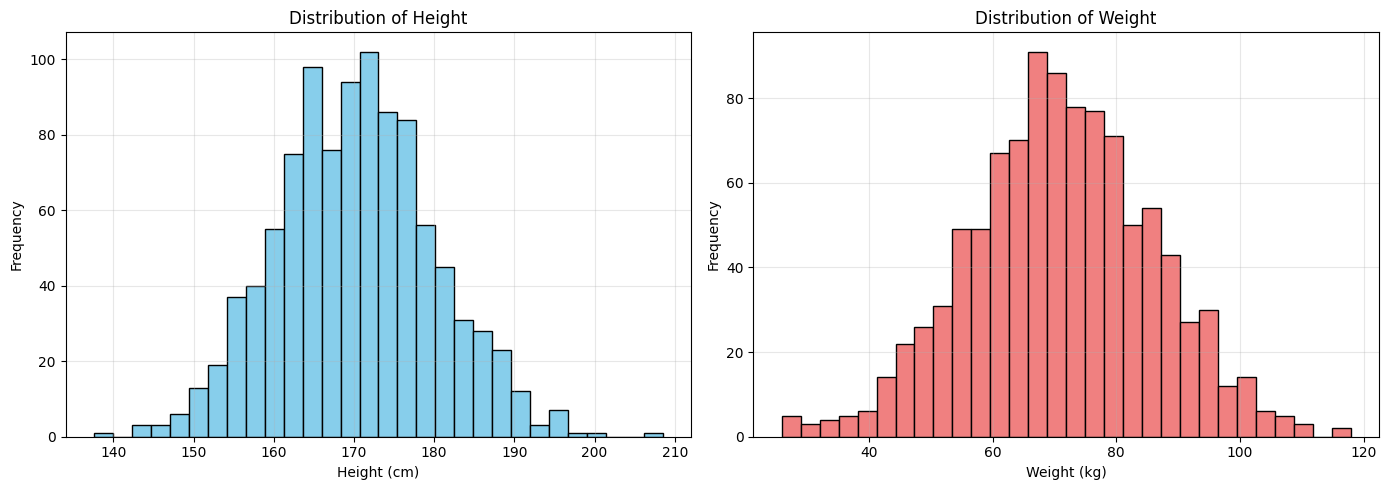

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["height_cm"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Height")
axes[0].grid(alpha=0.3)

axes[1].hist(df["weight_kg"], bins=30, color="lightcoral", edgecolor="black")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Weight")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

What this code chunk does

This makes two histograms:

height distribution
weight distribution
Why we use it

Plots help us visually understand the data.

Code pattern to remember
plt.subplots(...)
axes[i].hist(...)
plt.show()

This is the standard distribution plotting pattern.

Scatter plot by BMI category

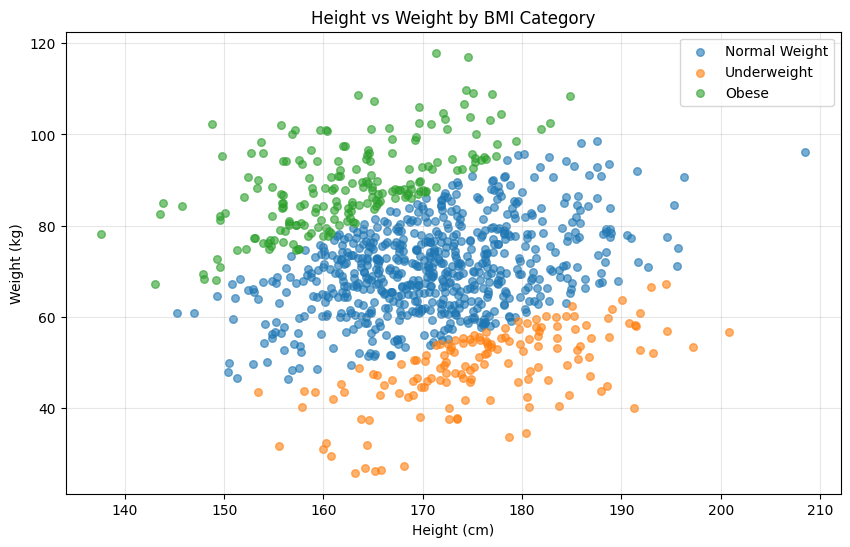

In [13]:
plt.figure(figsize=(10, 6))

for category in df["category"].unique():
    subset = df[df["category"] == category]
    plt.scatter(
        subset["height_cm"],
        subset["weight_kg"],
        label=category,
        alpha=0.6,
        s=30
    )

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight by BMI Category")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

What this code chunk does

This makes a scatter plot of:

x-axis = height
y-axis = weight
color/group = BMI category
Why we use it

This lets us see how the target categories separate in feature space.

Code pattern to remember
loop through classes
subset data
plot each class separately

This is the standard class-wise scatter plot pattern.

Prepare features and target

In [14]:
X = df[["height_cm", "weight_kg"]]
y = df["category"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 2)
Target shape: (1000,)


What this code chunk does

This defines:

X = the model inputs
y = the model target
Important

The model uses only:

height_cm
weight_kg

It does not use bmi as input, because BMI is directly related to the target category.

Why we use it

This is the standard machine learning setup.

Code pattern to remember
X = df[[feature1, feature2, ...]]
y = df[target]

This is the standard X/y split pattern.

Train/test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 800
Testing set size: 200


What this code chunk does

This splits data into:

training set = 80%
testing set = 20%

stratify=y keeps class balance similar in both sets.

Why we use it

The model should be evaluated on data it did not train on.

Code pattern to remember
train_test_split(X, y, test_size=..., random_state=..., stratify=y)

This is the standard train/test split pattern.

Create the model

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Model initialized successfully!")

Model initialized successfully!


What this code chunk does

This creates a random forest classifier.

Key parameter
n_estimators=100 → use 100 trees
Why we use it

Random forest is a strong, beginner-friendly model for tabular data.

Code pattern to remember
model = SomeClassifier(parameters)

This is the standard model initialization pattern.

Train the model

In [17]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


What this code chunk does

This teaches the random forest using the training data.

Why we use it

This is the learning step.

Code pattern to remember
model.fit(X_train, y_train)

This is the standard training pattern.

Make predictions and check accuracy

In [18]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 97.50%


What this code chunk does

This:

predicts BMI category on the test set
compares predictions to true labels
calculates accuracy
Why we use it

We need to know how well the model performs.

Code pattern to remember
y_pred = model.predict(X_test)
metric = accuracy_score(y_test, y_pred)

This is the standard prediction + metric pattern.

Classification  report

In [19]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Detailed Classification Report:
               precision    recall  f1-score   support

Normal Weight       0.98      0.98      0.98       131
        Obese       0.97      0.95      0.96        39
  Underweight       0.97      0.97      0.97        30

     accuracy                           0.97       200
    macro avg       0.97      0.97      0.97       200
 weighted avg       0.97      0.97      0.97       200



What this code chunk does

This prints:

precision
recall
f1-score
support

for each BMI category.

Why we use it

Accuracy alone is not enough.
We want per-class performance too.

Code pattern to remember
classification_report(y_true, y_pred)

This is the standard classification report pattern.

Confusion matrix  and heatmap

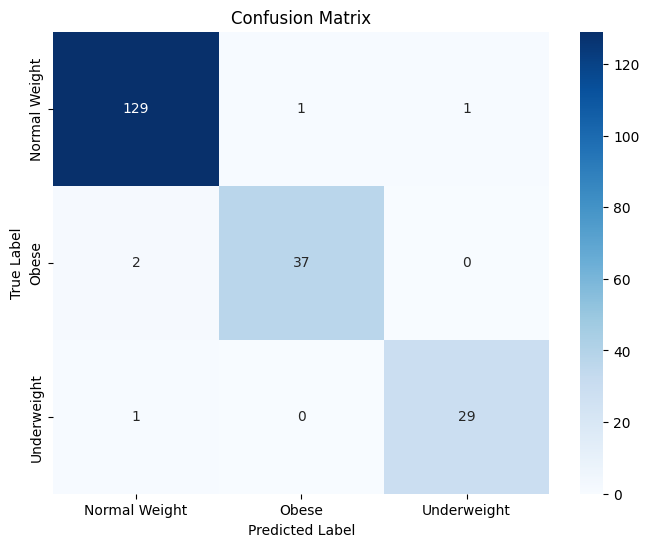

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

What this code chunk does

This builds and plots a confusion matrix.

Rows = true class
Columns = predicted class

Why we use it

This shows exactly where the model makes mistakes.

Code pattern to remember
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, ...)

This is the standard confusion matrix visualization pattern.

Feature importance

In [21]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
     feature  importance
1  weight_kg    0.721714
0  height_cm    0.278286


What this code chunk does

This shows which input features matter more to the random forest.

In this notebook, the features are:

height_cm
weight_kg
Why we use it

Feature importance helps interpret the model.

Code pattern to remember
pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

This is the standard feature importance pattern.

Plot feature importance

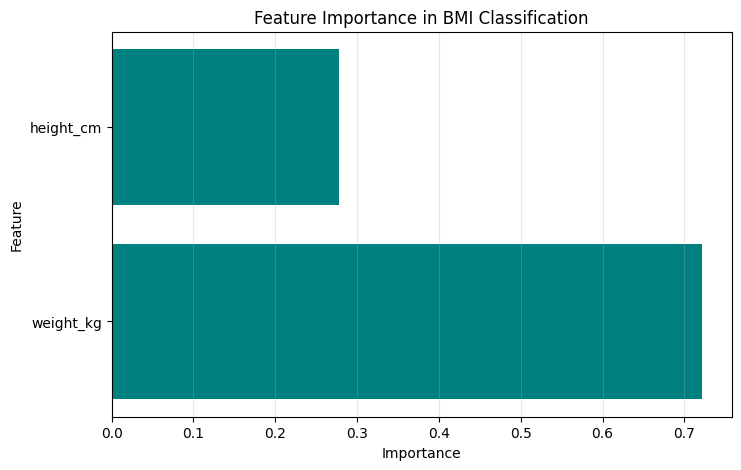

In [22]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"], color="teal")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in BMI Classification")
plt.grid(axis="x", alpha=0.3)
plt.show()

What this code chunk does

This plots the feature importance scores as a horizontal bar chart.

Why we use it

Visual charts are easier to understand than just numbers.

Code pattern to remember
plt.barh(feature_names, importance_values)

This is the standard importance bar chart pattern.

Save the trained model

In [28]:
model_filename = "bmi_classifier_model.pkl"

joblib.dump(model, model_filename)

print(f"Model saved successfully as '{model_filename}'!")

Model saved successfully as 'bmi_classifier_model.pkl'!


What this code chunk does

This saves the trained random forest model to disk.

Why we use it

Later, the Gradio app can load the saved model instead of retraining every time.

Code pattern to remember
joblib.dump(model, "filename.pkl")

This is the standard save-model pattern.

Build the real prediction function

In [32]:
def predict_bmi_category(height_cm, weight_kg):
    # Create a DataFrame with column names matching the training data
    input_data = pd.DataFrame([[height_cm, weight_kg]], columns=X.columns)

    prediction = loaded_model.predict(input_data)[0]

    bmi_value = weight_kg / ((height_cm / 100) ** 2)

    return f"Predicted Category: {prediction}\nCalculated BMI: {bmi_value:.2f}"

What this code chunk does

This is the most important deployment cell.

Step by step
Receive user input:
height
weight

Put inputs into the same shape the model expects:

np.array([[height_cm, weight_kg]])
Use the loaded model to predict a category
Also calculate BMI for reference
Return a readable text result
Why we use it

Gradio does not talk directly to the model.
It talks to a Python function.

So we wrap the model in a function.

Code pattern to remember
def predict_function(user_inputs):
    prepare input
    run model.predict(...)
    format output
    return result

This is the standard model wrapper function pattern.

Test the Prediction Function

In [33]:
loaded_model = joblib.load(model_filename)
test_result = predict_bmi_category(170, 70)
print("Test prediction:")
print(test_result)

Test prediction:
Predicted Category: Normal Weight
Calculated BMI: 24.22


What this code chunk does

This tests the prediction function with a sample patient:

height = 170 cm
weight = 70 kg
Why we use it

Before building the app, we make sure the function works.

Code pattern to remember
test function before deployment

This is a very good begin

Build the Gradio app using the real dataset inputs

In [34]:
demo_app = gr.Interface(
    fn=predict_bmi_category,

    inputs=[
        gr.Number(label="Height (cm)", value=170),
        gr.Number(label="Weight (kg)", value=70)
    ],

    outputs=gr.Textbox(lines=3, label="Prediction Result"),

    title="BMI Category Classifier",
    description="Enter height (cm) and weight (kg) to predict BMI category. This model classifies individuals as Underweight, Normal Weight, or Obese.",

    examples=[
        [160, 45],
        [175, 70],
        [165, 95]
    ],

    allow_flagging="never"
)

demo_app.launch(share=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

What this code chunk does

This creates the actual app.

Key parts
1. Function
fn=predict_bmi_category

This is the function the app runs.

2. Inputs
gr.Number(...)

The app asks the user for:

height in cm
weight in kg
3. Output
gr.Textbox(...)

The app shows prediction result text.

4. Title and description

These make the app easier to understand.

5. Examples

These let users try sample inputs quickly.

6. Launch
demo_app.launch(share=False)

starts the app.

Why we use it

This is the deployment step: turn a trained model into an interactive tool.

Code pattern to remember
app = gr.Interface(
    fn=prediction_function,
    inputs=[widgets],
    outputs=widget,
    title="...",
    description="...",
    examples=[...]
)

app.launch()

This is the standard Gradio deployment pattern.

switch number boxes to sliders

In [35]:
enhanced_demo = gr.Interface(
    fn=predict_bmi_category,
    inputs=[
        gr.Slider(minimum=140, maximum=210, value=170, label="Height (cm)"),
        gr.Slider(minimum=30, maximum=150, value=70, label="Weight (kg)")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="BMI Category Classifier (Enhanced)",
    description="Use sliders to adjust height and weight values.",
    examples=[
        [160, 45],
        [175, 70],
        [165, 95]
    ],
    allow_flagging="never"
)

enhanced_demo.launch(share=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

What this code chunk does

It improves the user interface by using sliders instead of number boxes.

Why we use it

A better interface is often easier for users.

Code pattern to remember
same prediction function
different input widgets

The UI can change without changing the model logic.

show prediction probabilities

In [36]:
def predict_with_confidence(height_cm, weight_kg):
    input_data = np.array([[height_cm, weight_kg]])

    prediction = loaded_model.predict(input_data)[0]
    probabilities = loaded_model.predict_proba(input_data)[0]

    bmi_value = weight_kg / ((height_cm / 100) ** 2)

    result = f"Predicted Category: {prediction}\n"
    result += f"Calculated BMI: {bmi_value:.2f}\n\n"
    result += "Confidence Scores:\n"

    for class_name, prob in zip(loaded_model.classes_, probabilities):
        result += f"{class_name}: {prob * 100:.2f}%\n"

    return result

What this code chunk does

This improved function returns:

predicted category
calculated BMI
confidence for each category
Why we use it

Users often want probability/confidence, not only the final label.

Code pattern to remember
predict(...)
predict_proba(...)
format readable result

This is the standard prediction + confidence pattern.

Gradio app with confidence scores

In [37]:
confidence_demo = gr.Interface(
    fn=predict_with_confidence,
    inputs=[
        gr.Slider(minimum=140, maximum=210, value=170, label="Height (cm)"),
        gr.Slider(minimum=30, maximum=150, value=70, label="Weight (kg)")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="BMI Category Classifier with Confidence",
    description="Predict BMI category and view confidence scores.",
    examples=[
        [160, 45],
        [175, 70],
        [165, 95]
    ],
    allow_flagging="never"
)

confidence_demo.launch(share=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

What this code chunk does

This makes a better app that shows:

predicted class
confidence scores
Why we use it

This is closer to how many medical decision-support tools work.

Full  workflow




install packages
→ import libraries
→ build small Gradio demos
→ generate synthetic dataset
→ calculate BMI
→ create category labels
→ build dataframe
→ inspect data
→ split into X and y
→ split train/test
→ train random forest
→ evaluate performance
→ save model
→ load model
→ wrap model in prediction function
→ build Gradio app
→ launch app